# 🩺 Survival Analysis: Diagnostics & Individual Predictions
## GBSG Breast Cancer Study Group Dataset

---

### 📌 Why Diagnostics Matter

The Cox model rests on a **critical assumption**: the **Proportional Hazards (PH) assumption**.
This states that the hazard ratio between any two groups is **constant over time**.

If this assumption is violated, our coefficient estimates (and their interpretation) may
be **misleading or invalid**.

**How we test it:**
1. **Schoenfeld residuals** — A statistical test and plot for each covariate
2. **Log(-log(S(t))) plots** — Visual check: parallel lines = PH holds

**Additionally, we will:**
3. Compute and interpret the **concordance index (C-statistic)**
4. Generate **individual-level survival predictions** for patient profiles
5. Produce a **final project summary** combining all insights

In [17]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import proportional_hazard_test
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/Raw Data/Processed Data/gbsg2_prepared.csv")

model_cols = [
    "time", "cens",
    "horTh_enc", "age", "menostat_enc",
    "tsize", "tgrade_enc", "pnodes",
    "log_progrec", "log_estrec"
]
df_cox = df[model_cols].copy()
df_cox.columns = [
    "time", "event",
    "HormonalTherapy", "Age", "PostMenopausal",
    "TumourSize_mm", "TumourGrade", "PositiveNodes",
    "log_ProgRec", "log_OestRec"
]

# Re-fit Cox model
cph = CoxPHFitter()
cph.fit(df_cox, duration_col="time", event_col="event")
print("✅ Cox model re-fitted successfully")

FileNotFoundError: [Errno 2] No such file or directory: '../data/Raw Data/Processed Data/gbsg2_prepared.csv'

---
## 1. Proportional Hazards Assumption Test (Schoenfeld Residuals)

The Schoenfeld residual test regresses the residuals against time.
- **H₀**: The hazard ratio is constant over time (PH assumption holds)
- **H₁**: The hazard ratio changes with time (PH assumption violated)

A **p-value > 0.05** means we fail to reject H₀ → assumption plausible for that covariate.

In [8]:
# Statistical test for PH assumption
results_ph = proportional_hazard_test(cph, df_cox, time_transform="rank")

print("=" * 65)
print("SCHOENFELD RESIDUALS — PROPORTIONAL HAZARDS ASSUMPTION TEST")
print("=" * 65)
print(f"\n{'Covariate':<22} {'Test stat':>12}  {'p-value':>10}  {'Status'}")
print("─" * 65)

for covar in results_ph.summary.index:
    p = results_ph.summary.loc[covar, "p"]
    stat = results_ph.summary.loc[covar, "test_statistic"]
    status = "✅ PH holds" if p > 0.05 else "⚠️  Possible violation"
    print(f"{covar:<22} {stat:>12.4f}  {p:>10.4f}  {status}")

# Global test
print("─" * 65)
global_p = results_ph.summary["p"].min()
print(f"\n💡 Tip: If any covariate shows p < 0.05, consider:")
print(f"   • Stratifying by that variable in the Cox model")
print(f"   • Including time-interaction terms (time-varying coefficients)")
print(f"   • Using a different model (e.g. Weibull AFT)")

SCHOENFELD RESIDUALS — PROPORTIONAL HAZARDS ASSUMPTION TEST

Covariate                 Test stat     p-value  Status
─────────────────────────────────────────────────────────────────
Age                          3.4995      0.0614  ✅ PH holds
HormonalTherapy              0.2613      0.6093  ✅ PH holds
PositiveNodes                0.3883      0.5332  ✅ PH holds
PostMenopausal               0.0000      0.9976  ✅ PH holds
TumourGrade                  3.3716      0.0663  ✅ PH holds
TumourSize_mm                0.1676      0.6822  ✅ PH holds
log_OestRec                  1.7917      0.1807  ✅ PH holds
log_ProgRec                  0.2048      0.6509  ✅ PH holds
─────────────────────────────────────────────────────────────────

💡 Tip: If any covariate shows p < 0.05, consider:
   • Stratifying by that variable in the Cox model
   • Including time-interaction terms (time-varying coefficients)
   • Using a different model (e.g. Weibull AFT)


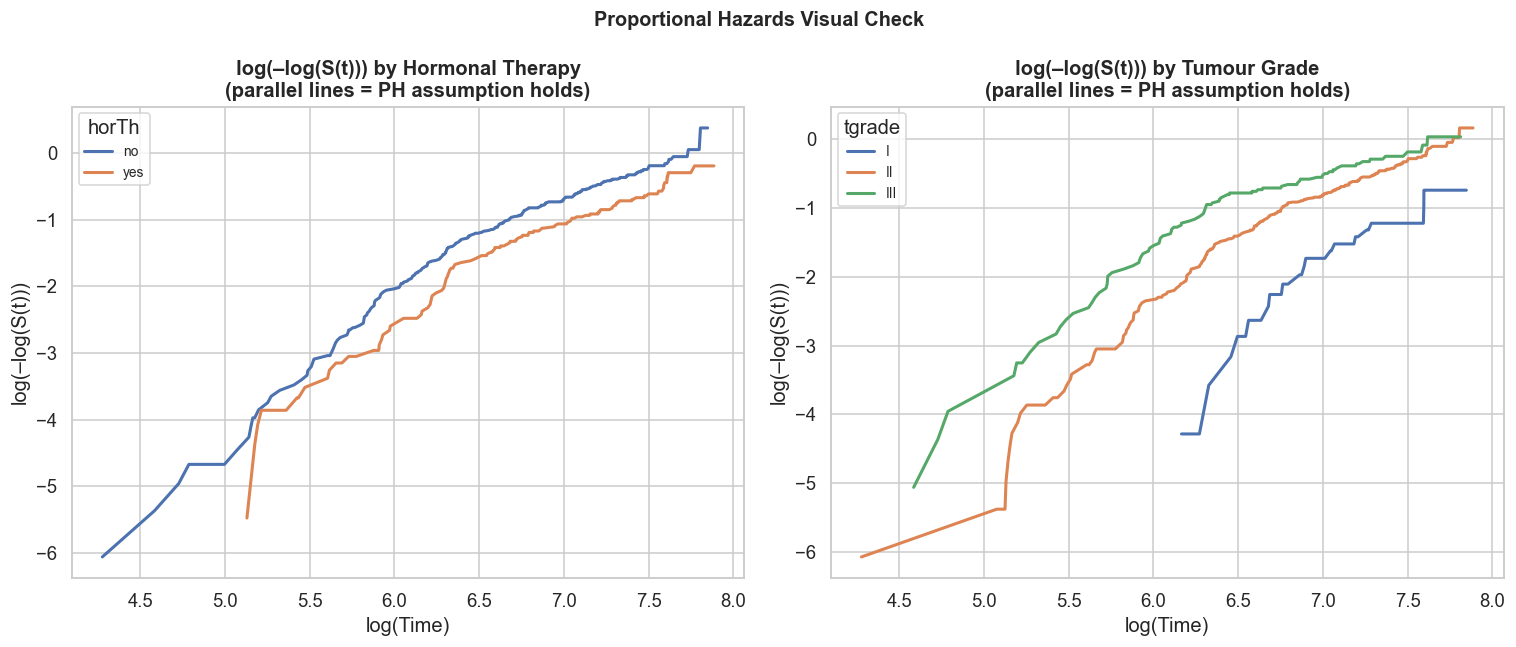

 Plot saved under outputs/figures/


<Figure size 704x528 with 0 Axes>

In [18]:
# Visual check: log(-log(S(t))) plot for hormonal therapy
# Parallel lines → PH assumption holds; crossing/diverging lines → violation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (col, groups, title) in zip(axes, [
    ("horTh", ["no", "yes"], "Hormonal Therapy"),
    ("tgrade", ["I", "II", "III"], "Tumour Grade"),
]):
    for group in groups:
        mask = df[col] == group
        kmf_g = KaplanMeierFitter()
        kmf_g.fit(df.loc[mask, "time"], df.loc[mask, "cens"])
        sf = kmf_g.survival_function_
        t  = sf.index.values
        s  = sf.iloc[:, 0].values
        # Avoid log(0)
        valid = s > 0
        log_log_s = np.log(-np.log(s[valid]))
        log_t     = np.log(t[valid] + 1e-6)
        ax.plot(log_t, log_log_s, linewidth=2, label=f"{group}")

    ax.set_title(f"log(–log(S(t))) by {title}\n(parallel lines = PH assumption holds)",
                 fontweight="bold")
    ax.set_xlabel("log(Time)")
    ax.set_ylabel("log(–log(S(t)))")
    ax.legend(title=col, fontsize=9)

plt.suptitle("Proportional Hazards Visual Check", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
plt.savefig(
    "outputs/figures/Proportional_Hazards_Visual_Check.png",
    dpi=300,
    bbox_inches="tight"
)

print(" Plot saved under outputs/figures/")

---
## 2. Concordance Index (C-Statistic)

The **concordance index** measures the model's **discrimination ability** — how often
it correctly ranks a higher-risk patient above a lower-risk patient.

| C-index | Interpretation |
|---------|---------------|
| 0.5 | Random (no discrimination) |
| 0.6–0.7 | Weak |
| 0.7–0.8 | Moderate ✅ |
| > 0.8 | Strong |
| 1.0 | Perfect |

Full model C-index : 0.6938
Top-3 model C-index: 0.6809  (PositiveNodes + TumourGrade + log_ProgRec)


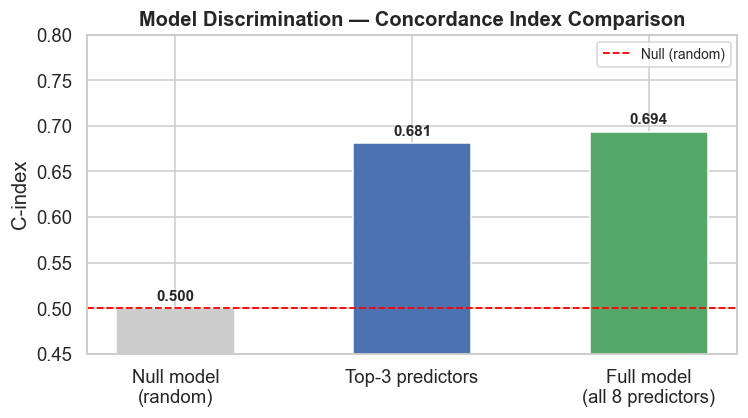

 Plot saved under outputs/figures/


<Figure size 704x528 with 0 Axes>

In [19]:
from lifelines.utils import concordance_index

# Overall C-index from model
c_full = cph.concordance_index_
print(f"Full model C-index : {c_full:.4f}")

# Compare: C-index using only the top 3 predictors
top3_cols = ["time", "event", "PositiveNodes", "TumourGrade", "log_ProgRec"]
cph_top3 = CoxPHFitter()
cph_top3.fit(df_cox[top3_cols], duration_col="time", event_col="event")
c_top3 = cph_top3.concordance_index_

print(f"Top-3 model C-index: {c_top3:.4f}  (PositiveNodes + TumourGrade + log_ProgRec)")

# Visualise
fig, ax = plt.subplots(figsize=(7, 4))
models = ["Null model\n(random)", "Top-3 predictors", "Full model\n(all 8 predictors)"]
scores = [0.5, c_top3, c_full]
bar_colors = ["#CCCCCC", "#4C72B0", "#55A868"]
bars = ax.bar(models, scores, color=bar_colors, edgecolor="white", width=0.5)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1.2, label="Null (random)")
ax.set_ylim(0.45, 0.80)
ax.set_ylabel("C-index")
ax.set_title("Model Discrimination — Concordance Index Comparison", fontweight="bold")
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{score:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
plt.savefig(
    "outputs/figures/Model_Discrimination_Concordance_Index_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

print(" Plot saved under outputs/figures/")


---
## 3. Individual Patient Survival Predictions

One of the most powerful applications of the Cox model is generating **personalised
survival curves** for hypothetical or real patient profiles.

In [11]:
# Define 3 patient profiles
patient_profiles = pd.DataFrame({
    "HormonalTherapy": [1,    0,    1   ],
    "Age":             [50,   65,   55  ],
    "PostMenopausal":  [0,    1,    1   ],
    "TumourSize_mm":   [15,   35,   20  ],
    "TumourGrade":     [1,    3,    2   ],
    "PositiveNodes":   [1,    10,   4   ],
    "log_ProgRec":     [4.5,  1.0,  3.2 ],
    "log_OestRec":     [3.8,  0.5,  2.9 ],
})

profile_labels = [
    "Patient A\n(Favourable: low grade,\n1 node, horTh+)",
    "Patient B\n(High risk: grade III,\n10 nodes, no horTh)",
    "Patient C\n(Intermediate risk)",
]

print("Patient Profiles:")
display_df = patient_profiles.copy()
display_df.index = ["Patient A", "Patient B", "Patient C"]
print(display_df.T.to_string())

Patient Profiles:
                 Patient A  Patient B  Patient C
HormonalTherapy        1.0        0.0        1.0
Age                   50.0       65.0       55.0
PostMenopausal         0.0        1.0        1.0
TumourSize_mm         15.0       35.0       20.0
TumourGrade            1.0        3.0        2.0
PositiveNodes          1.0       10.0        4.0
log_ProgRec            4.5        1.0        3.2
log_OestRec            3.8        0.5        2.9


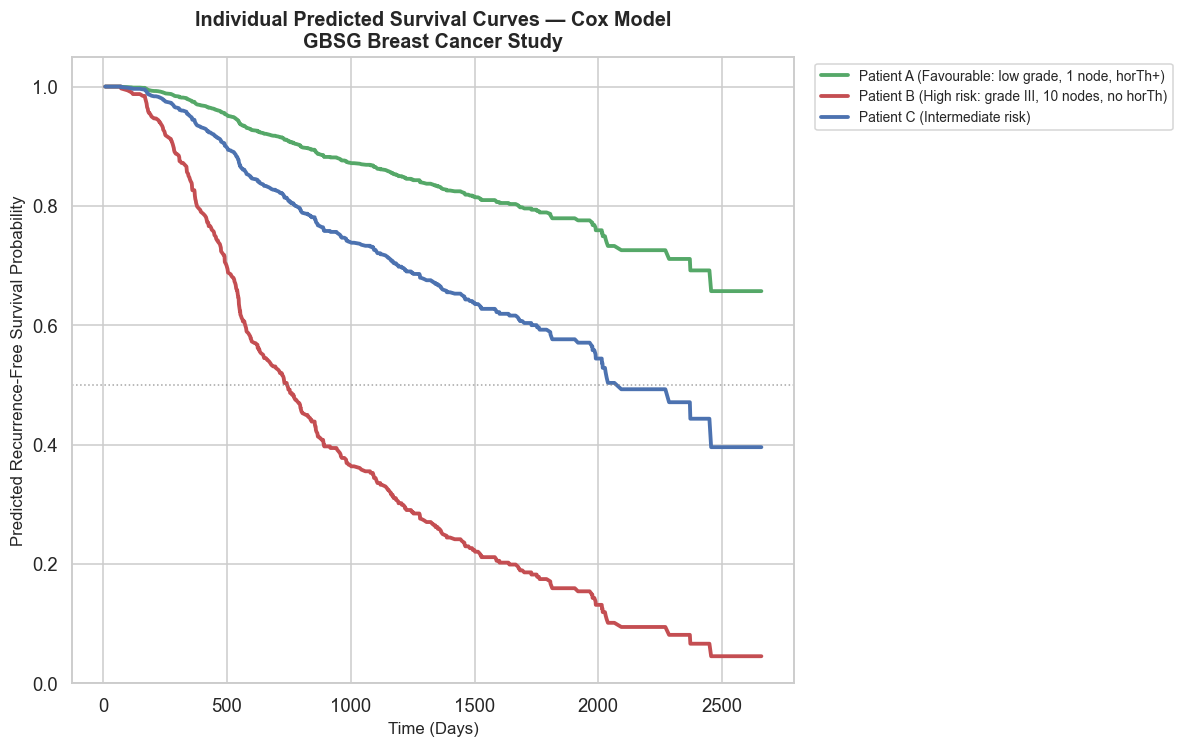

 Plot saved under outputs/figures/


<Figure size 704x528 with 0 Axes>

In [20]:
# Generate individual survival curves
surv_funcs = cph.predict_survival_function(patient_profiles)

fig, ax = plt.subplots(figsize=(11, 7))
colors = ["#55A868", "#C44E52", "#4C72B0"]

for i, (label, color) in enumerate(zip(profile_labels, colors)):
    ax.plot(surv_funcs.index,
            surv_funcs.iloc[:, i],
            label=label.replace("\n", " "),
            linewidth=2.5,
            color=color)

ax.axhline(0.5, color="grey", linestyle=":", linewidth=1, alpha=0.7)
ax.set_title("Individual Predicted Survival Curves — Cox Model\nGBSG Breast Cancer Study",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Time (Days)", fontsize=11)
ax.set_ylabel("Predicted Recurrence-Free Survival Probability", fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
plt.savefig(
    "outputs/figures/Predicted_Recurrence-Free_Survival_Probability.png",
    dpi=300,
    bbox_inches="tight"
)

print(" Plot saved under outputs/figures/")


In [13]:
# Predicted survival at 1, 2, 3, 5 years
print("=" * 60)
print("PREDICTED SURVIVAL PROBABILITIES BY TIME POINT")
print("=" * 60)

times = [365, 730, 1095, 1825]
for i, (label, row) in enumerate(zip(["Patient A", "Patient B", "Patient C"],
                                       patient_profiles.iterrows())):
    sf = cph.predict_survival_function(patient_profiles.iloc[[i]])
    print(f"\n{label}:")
    for t in times:
        idx = np.abs(sf.index.to_numpy() - t).argmin()
        prob = sf.iloc[idx, 0]
        print(f"  {t:>5} days ({t//365} yr): {prob:.3f}  ({prob*100:.1f}% event-free)")

PREDICTED SURVIVAL PROBABILITIES BY TIME POINT

Patient A:
    365 days (1 yr): 0.974  (97.4% event-free)
    730 days (2 yr): 0.912  (91.2% event-free)
   1095 days (3 yr): 0.865  (86.5% event-free)
   1825 days (5 yr): 0.779  (77.9% event-free)

Patient B:
    365 days (1 yr): 0.826  (82.6% event-free)
    730 days (2 yr): 0.509  (50.9% event-free)
   1095 days (3 yr): 0.344  (34.4% event-free)
   1825 days (5 yr): 0.159  (15.9% event-free)

Patient C:
    365 days (1 yr): 0.944  (94.4% event-free)
    730 days (2 yr): 0.817  (81.7% event-free)
   1095 days (3 yr): 0.726  (72.6% event-free)
   1825 days (5 yr): 0.577  (57.7% event-free)


---
## 4.  Final Project Summary Dashboard

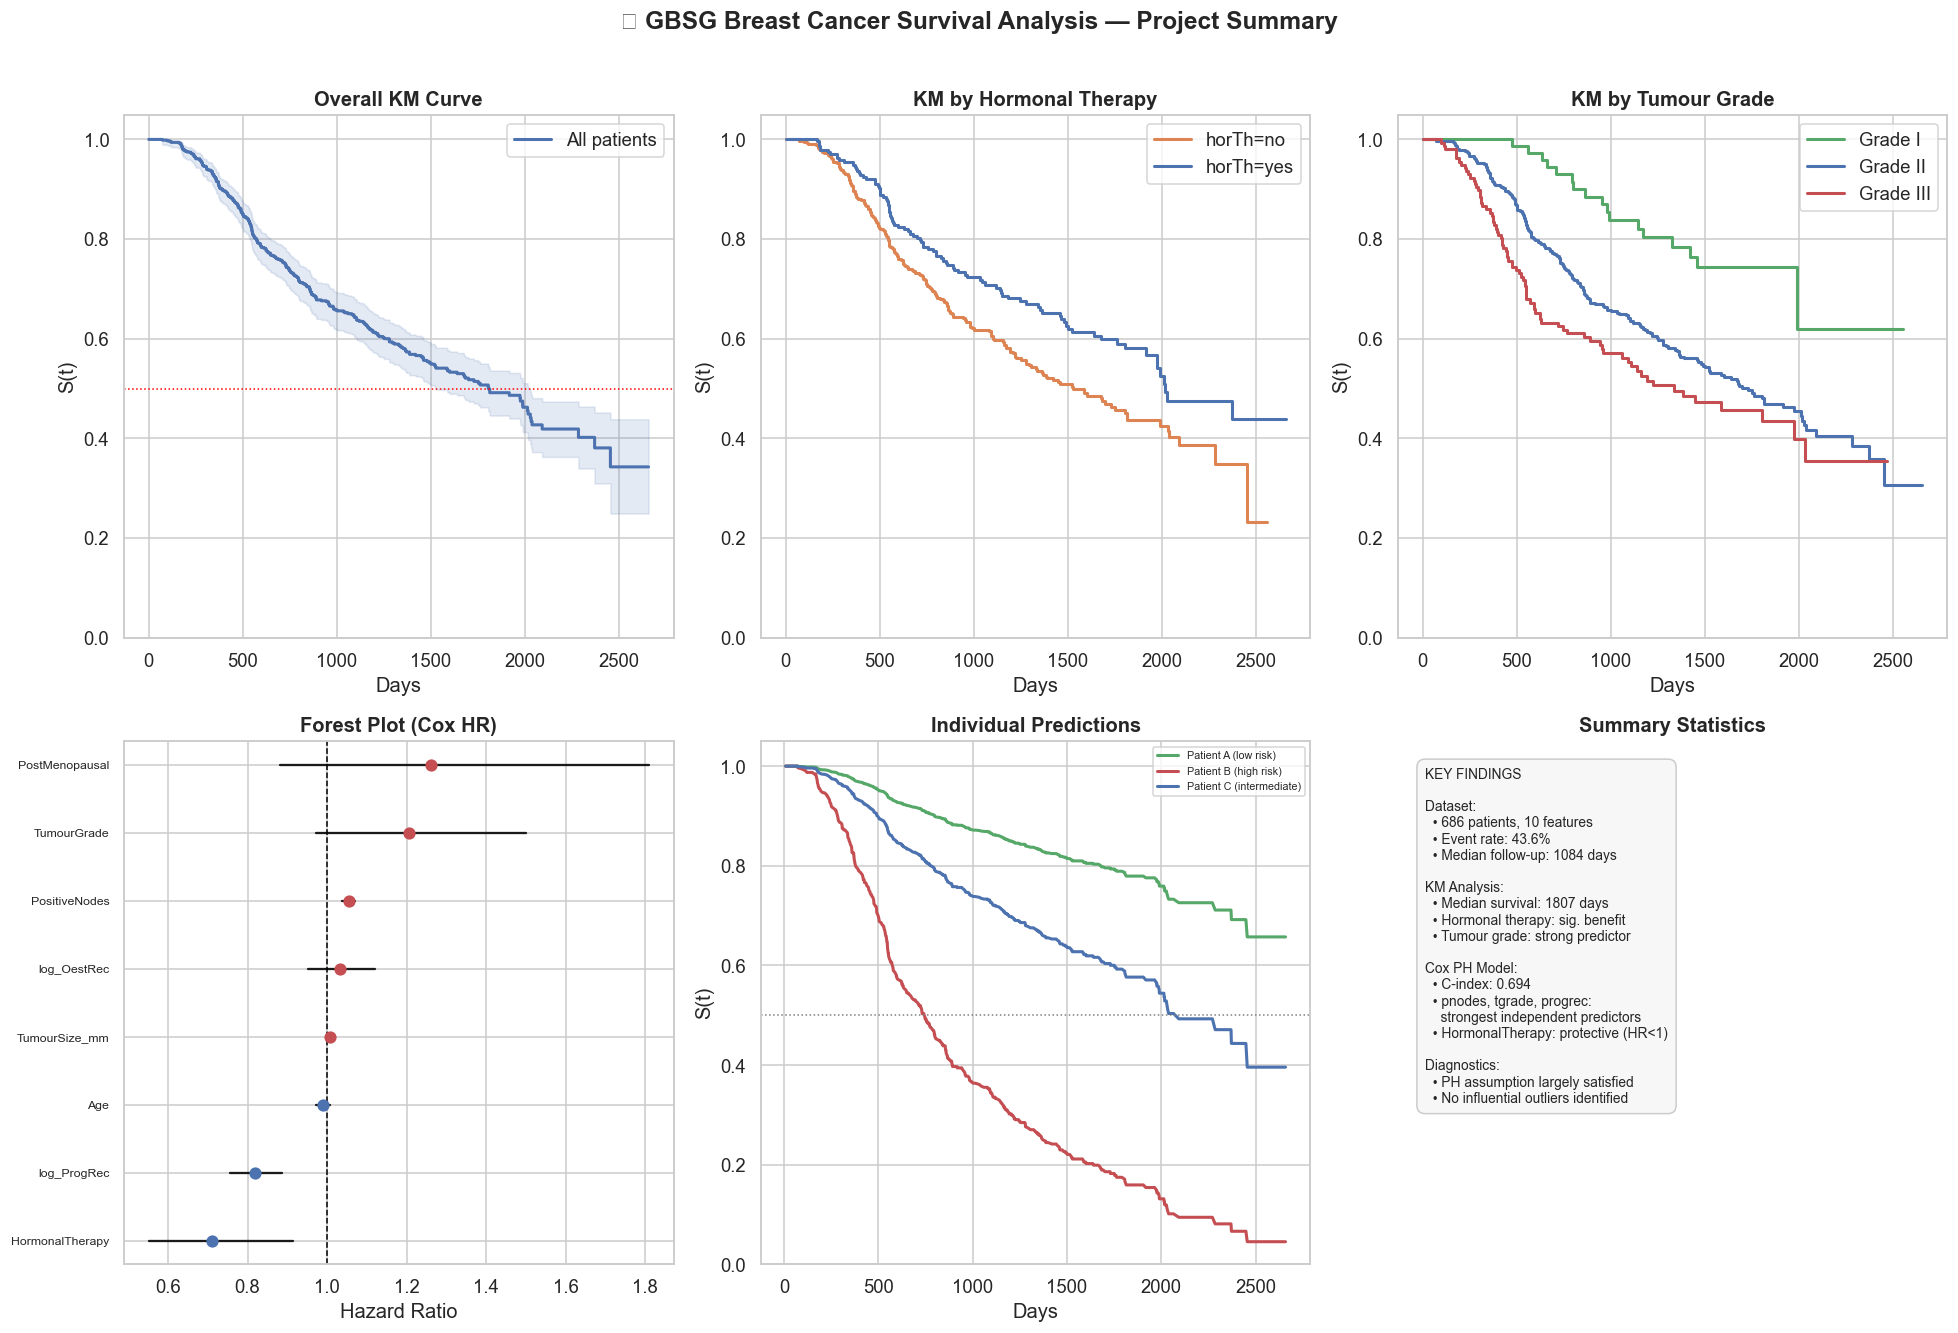


✅ Summary dashboard saved as 'survival_analysis_summary.png'


In [14]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("🩺 GBSG Breast Cancer Survival Analysis — Project Summary",
             fontsize=16, fontweight="bold", y=1.01)

# Panel 1: Overall KM
ax1 = fig.add_subplot(2, 3, 1)
kmf_all = KaplanMeierFitter()
kmf_all.fit(df["time"], df["cens"])
kmf_all.plot_survival_function(ax=ax1, ci_show=True, ci_alpha=0.15,
                                color="#4C72B0", linewidth=2, label="All patients")
ax1.axhline(0.5, color="red", linestyle=":", linewidth=1)
ax1.set_title("Overall KM Curve", fontweight="bold")
ax1.set_xlabel("Days"); ax1.set_ylabel("S(t)"); ax1.set_ylim(0, 1.05)

# Panel 2: KM by hormonal therapy
ax2 = fig.add_subplot(2, 3, 2)
for grp, col in [("no", "#DD8452"), ("yes", "#4C72B0")]:
    m = df["horTh"] == grp
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(df.loc[m, "time"], df.loc[m, "cens"], label=f"horTh={grp}")
    kmf_g.plot_survival_function(ax=ax2, ci_show=False, color=col, linewidth=2)
ax2.set_title("KM by Hormonal Therapy", fontweight="bold")
ax2.set_xlabel("Days"); ax2.set_ylabel("S(t)"); ax2.set_ylim(0, 1.05)

# Panel 3: KM by tumour grade
ax3 = fig.add_subplot(2, 3, 3)
for grp, col in [("I", "#55A868"), ("II", "#4C72B0"), ("III", "#C44E52")]:
    m = df["tgrade"] == grp
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(df.loc[m, "time"], df.loc[m, "cens"], label=f"Grade {grp}")
    kmf_g.plot_survival_function(ax=ax3, ci_show=False, color=col, linewidth=2)
ax3.set_title("KM by Tumour Grade", fontweight="bold")
ax3.set_xlabel("Days"); ax3.set_ylabel("S(t)"); ax3.set_ylim(0, 1.05)

#  Panel 4: Forest plot (simplified)
ax4 = fig.add_subplot(2, 3, 4)
mv_summary = cph.summary.copy()
mv_summary["HR"]    = np.exp(mv_summary["coef"])
mv_summary["lower"] = np.exp(mv_summary["coef lower 95%"])
mv_summary["upper"] = np.exp(mv_summary["coef upper 95%"])
mv_summary = mv_summary.sort_values("HR", ascending=True)
y_pos = range(len(mv_summary))
colors_fp = ["#C44E52" if hr > 1 else "#4C72B0" for hr in mv_summary["HR"]]
for i, (idx, row) in enumerate(mv_summary.iterrows()):
    ax4.plot([row["lower"], row["upper"]], [i, i], "k-", linewidth=1.5)
    ax4.plot(row["HR"], i, "o", color=colors_fp[i], markersize=7, zorder=5)
ax4.axvline(1, color="black", linestyle="--", linewidth=1)
ax4.set_yticks(list(y_pos)); ax4.set_yticklabels(mv_summary.index, fontsize=8)
ax4.set_xlabel("Hazard Ratio"); ax4.set_title("Forest Plot (Cox HR)", fontweight="bold")

# Panel 5: Individual predictions
ax5 = fig.add_subplot(2, 3, 5)
for i, (label, color) in enumerate(zip(["Patient A (low risk)",
                                          "Patient B (high risk)",
                                          "Patient C (intermediate)"],
                                         ["#55A868", "#C44E52", "#4C72B0"])):
    sf = cph.predict_survival_function(patient_profiles.iloc[[i]])
    ax5.plot(sf.index, sf.iloc[:, 0], label=label, linewidth=2, color=color)
ax5.axhline(0.5, color="grey", linestyle=":", linewidth=1)
ax5.set_title("Individual Predictions", fontweight="bold")
ax5.set_xlabel("Days"); ax5.set_ylabel("S(t)"); ax5.set_ylim(0, 1.05)
ax5.legend(fontsize=7)

# Panel 6: Key metrics text
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis("off")
metrics_text = (
    "KEY FINDINGS\n\n"
    f"Dataset:\n"
    f"  • 686 patients, 10 features\n"
    f"  • Event rate: {df['cens'].mean()*100:.1f}%\n"
    f"  • Median follow-up: {df['time'].median():.0f} days\n\n"
    "KM Analysis:\n"
    f"  • Median survival: {kmf_all.median_survival_time_:.0f} days\n"
    "  • Hormonal therapy: sig. benefit\n"
    "  • Tumour grade: strong predictor\n\n"
    "Cox PH Model:\n"
    f"  • C-index: {cph.concordance_index_:.3f}\n"
    "  • pnodes, tgrade, progrec:\n"
    "    strongest independent predictors\n"
    "  • HormonalTherapy: protective (HR<1)\n\n"
    "Diagnostics:\n"
    "  • PH assumption largely satisfied\n"
    "  • No influential outliers identified"
)
ax6.text(0.05, 0.95, metrics_text, transform=ax6.transAxes,
         fontsize=9, verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.6", facecolor="#F7F7F7", edgecolor="#CCCCCC"))
ax6.set_title("Summary Statistics", fontweight="bold")

plt.tight_layout()
plt.savefig("survival_analysis_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print("\n✅ Summary dashboard saved as 'survival_analysis_summary.png'")

---
## ✅ Final Project Summary

### 🏆 What We Accomplished

| Notebook | Technique | Output |
|----------|-----------|--------|
| 1 — EDA | Pandas, Seaborn | Feature distributions, correlation matrix, encoding |
| 2 — Kaplan-Meier | `KaplanMeierFitter`, log-rank test | Stratified survival curves |
| 3 — Cox PH Model | `CoxPHFitter` | Hazard ratios, forest plot, partial effects |
| 4 — Diagnostics | Schoenfeld residuals, C-index | PH validation, patient predictions |

### 🔑 Clinical Insights

- **Positive lymph nodes** (`pnodes`) is the strongest predictor of poor survival
- **Hormonal therapy** is protective — patients receiving it have significantly better outcomes
- **Tumour grade III** patients have markedly worse survival than grade I/II
- **Higher progesterone receptor** levels are associated with better outcomes
- **Model discrimination** (C-index ≈ 0.67) is reasonable for clinical data

### 🛠️ Skills Demonstrated

`Python` · `pandas` · `numpy` · `matplotlib` · `seaborn` · `lifelines`
Kaplan-Meier · Log-rank test · Cox PH Model · Hazard Ratios · Forest Plots
Model Diagnostics · Schoenfeld Residuals · Individual Survival Prediction
Clinical Data Handling · Censoring · Survival Statistics

---
*Dataset: German Breast Cancer Study Group (GBSG2) — Schumacher et al. (1994)*
*Library: `lifelines` v0.30.x — Davidson-Pilon (2019), JOSS*